# Exercises 2

## Exercise 2.1

We are asked to compute the following integral:
$$
I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1
$$

Using Monte Carlo, and: 
1. a uniform distribution in [0, 1)
2. importance sampling, so a non-uniform distribution in [0, 1) 

### Monte Carlo Integration

We can approximate an integral as:
$$
I = \int_a^b f(x) \mathrm{d}x  =\\
= \lim_{N \to \infty} \sum_{i=1}^N\Delta x_i \cdot f(x_i) = \\ \underset{\Delta x_i = \frac{b-a}{N}}{=} (b - a) \lim_{N \to \infty} \frac{1}{N} \sum_{i=1}^N f(x_i) =\\

= (b - a) \langle f \rangle_{[a, b]}
$$

Where $\langle f \rangle_{[a, b]}$ is any kind of estimator of the function $f$ over $[a, b]$. In this way we can use different estimators for different cases, for example we can use Monte Carlo estimator for high dimension integrals because it is not dimension-dependant, or we could use Gauss-Legendre integration for spherical 3d domains.

### Importance Sampling

Keeping our discussion about Monte Carlo methods, we can achieve a better result if we change the distribution we sample from. A generic integral can be expressed as:
$$
I = \int_\Omega f(\vec x) p(\vec x) \mathrm{d} \vec x
$$
Where $f$ is a generic function and $p(\vec x)$ is a probability density function.

It's variance is:

$$
\sigma_I^2 = \int_\Omega f^2(\vec x) p(\vec x) \mathrm{d} \vec x - I^2
$$

We can rewrite the integral as:
$$
I = \int_\Omega \frac{f(\vec x) p(\vec x)}{q(\vec x)}  q(\vec x)\mathrm{d} \vec x
$$
Where $q(\vec x)$ is a normalized probability density function, which respect the constrain: $\frac{f(\vec x) p(\vec x)}{q(\vec x)} < \infty$ almost everywhere.

It's variance will be:
$$
{\sigma'}_I^2 = \int_\Omega \left[\frac{f(\vec x) p(\vec x)}{q(\vec x)}\right]^2 q(\vec x)\mathrm{d} \vec x - I^2
$$

**Which is different** from $\sigma_I^2$, so we want to find $q(\vec x)$ which minimizes the variance.

The distribution that minimizes the variance is simply the (normalized) function we want to integrate:
$$
q(\vec x) = \frac{f(\vec x) p(\vec x)}{I}
$$

But we don't already know $I$, instead we can use:
$$
q(\vec x) \approx f(\vec x) p(\vec x)
$$
And normalize later.

In this way we still get a solution **near** the minimum.

### Numerical Implementation

So we want to use $q(x) \approx \cos(\pi x/2)$, using a taylor expansion in $x = 0$ and in $x = 1$ we get:

$$
\cos(\pi x/2) \underset{x \sim 0}{\approx} 1 - \frac{1}{2}\left(\frac{\pi}{2}\right)^2 x^2 + \mathcal{O}(x^4) 
$$
$$
\cos(\pi x/2) \underset{x \sim 1}{\approx} -\frac{\pi}{2}(x-1) + \mathcal{O}(x^3) 
$$

We can note that the expansion in zero does not give us a good result, because it becomes negative for $x > 0.9$, so we will use the expansion in $x = 1$.

Before we use $q(x) = \frac{\pi}{2}(1 -x)$ we have to normalize it between $[0, 1]$, which becomes: 

$$
q(x) = 2(1 -x)
$$

Our integral then becomes:

$$
I = \frac{\pi}{2}\int_0^1 \frac{\cos(\pi x/2)}{2(1 -x)} q(x) \mathrm{d}x
$$

Where we sample using $q(x)$ which is given by inverting the CDF of $q$ and generating $y\in \mathcal{U}[0, 1)$, so $q(x) = 1 - \sqrt{1 - y}$, with $y$ uniformly distributed in $[0, 1)$.

In [1]:
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

In [2]:
def plot_integral(filename: str, expected_value: float, title: str) -> None:
    data = np.loadtxt(filename)

    blocks = np.arange(data.shape[0])
    averages = data[:, 0]
    errors = data[:, 1]

    plt.errorbar(blocks, averages, errors, label="Simulation")
    plt.plot(blocks, expected_value * np.ones_like(blocks), label="Expected")

    plt.xlabel("Number of blocks")
    plt.ylabel("Mean Value of the integral")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.plot()

We now compare the results obtained with the uniform distribution and the importance sampling.

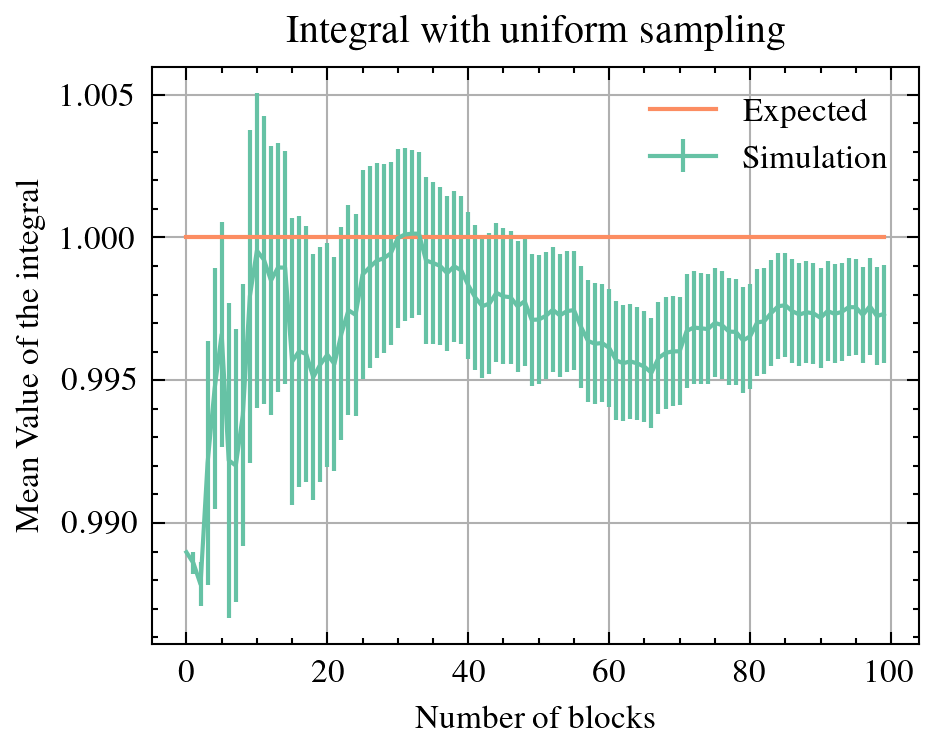

In [3]:
plot_integral("./Exer_02_01/integral_uniform.dat", 1, "Integral with uniform sampling")

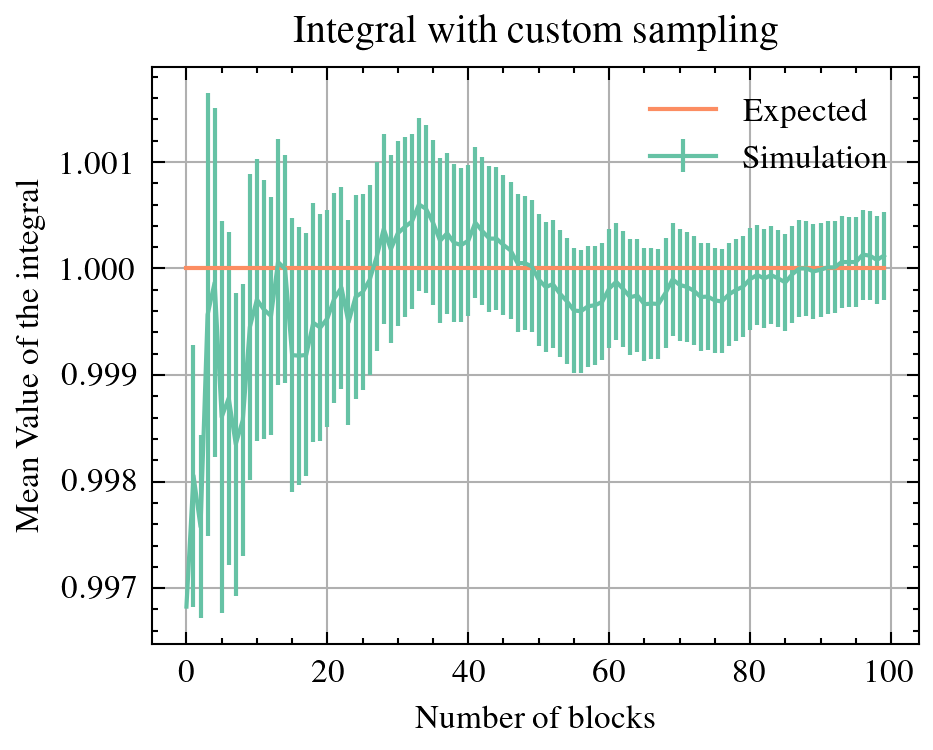

In [4]:
plot_integral("./Exer_02_01/integral_custom.dat", 1, "Integral with custom sampling")

We can see that both integrals give a value near the true value, but the integral with importance sampling has a variance around 5 times smaller!. If we search for the same error the method with uniform distribution would need around 25 times the computational time of the second one!.

## Exercise 2.2

We are asked to simulate a 3D Random Walk on a cubit lattice and in the continuum.

### Random Walk

A random walk is a stochastic process which follows the rule:
$$
\vec r_{i+1} = \vec r_{i} + \vec l(i)
$$
Which means that the next position $\vec r_{i+1}$ is equal to the current position $\vec r_{i}$ plus a random step in some direction $\vec l(i)$.

On our simulations we will start from the origin: $\vec r_0 = (0, 0, 0)$.

#### Cubic Lattice Random Walk

For the cubic lattice random walk we define the step size $a = 1$, which is also the size of our lattice. So the position at each time step is fixed to a point $\vec r_i = (n_x \cdot a, n_y \cdot a, n_z \cdot a)$, where $n_x, n_y, n_z$ are integers.

So for determining the next step $\vec l(i)$ we just need to choose a verse and direction to go. For this I simply extract a uniform random number in the range $[0, 6)$ and the integer part will give the direction and verse.

#### Continuos Random Walk

In the continuum there is no constrain for the position, but we will constrain the step size to length $a =1$.

Then for determining the next step $\vec l(i)$ we just need to sample a random direction to move in the 3d space. We achieve this by simply extracting two random angles: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$, which gives us $\vec l$ in spherical coordinates, we then convert it to cartesian coordinates for summation simplicity. 

### Simulations

In the code we simulated both random walks for 100 steps each. We used data blocking on 100 simulations per block and a total of 100 blocks.

Below are the pictures of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both random walks as a function of the step $i \in [0, 10^2]$.

In [5]:
def plot_random_walk(filename: str, title: str) -> None:
    data = np.loadtxt(filename)

    steps = np.arange(data.shape[0])
    averages = data[:, 0]
    errors = data[:, 1]

    expected_value = np.sqrt(steps)

    residuals = averages - expected_value

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    ax1.errorbar(steps, averages, yerr=errors, label="Simulation")
    ax1.plot(steps, expected_value, label="Expected")

    ax1.set_xlabel("Number of steps")
    ax1.set_ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
    ax1.legend()
    ax1.grid(True)

    ax2.errorbar(steps, residuals, yerr=errors, label="Residuals", ls=":", marker=".")
    ax2.plot(steps, np.zeros_like(steps), label="Expected")

    ax2.set_xlabel("Number of steps")
    ax2.set_ylabel(r"Residuals of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

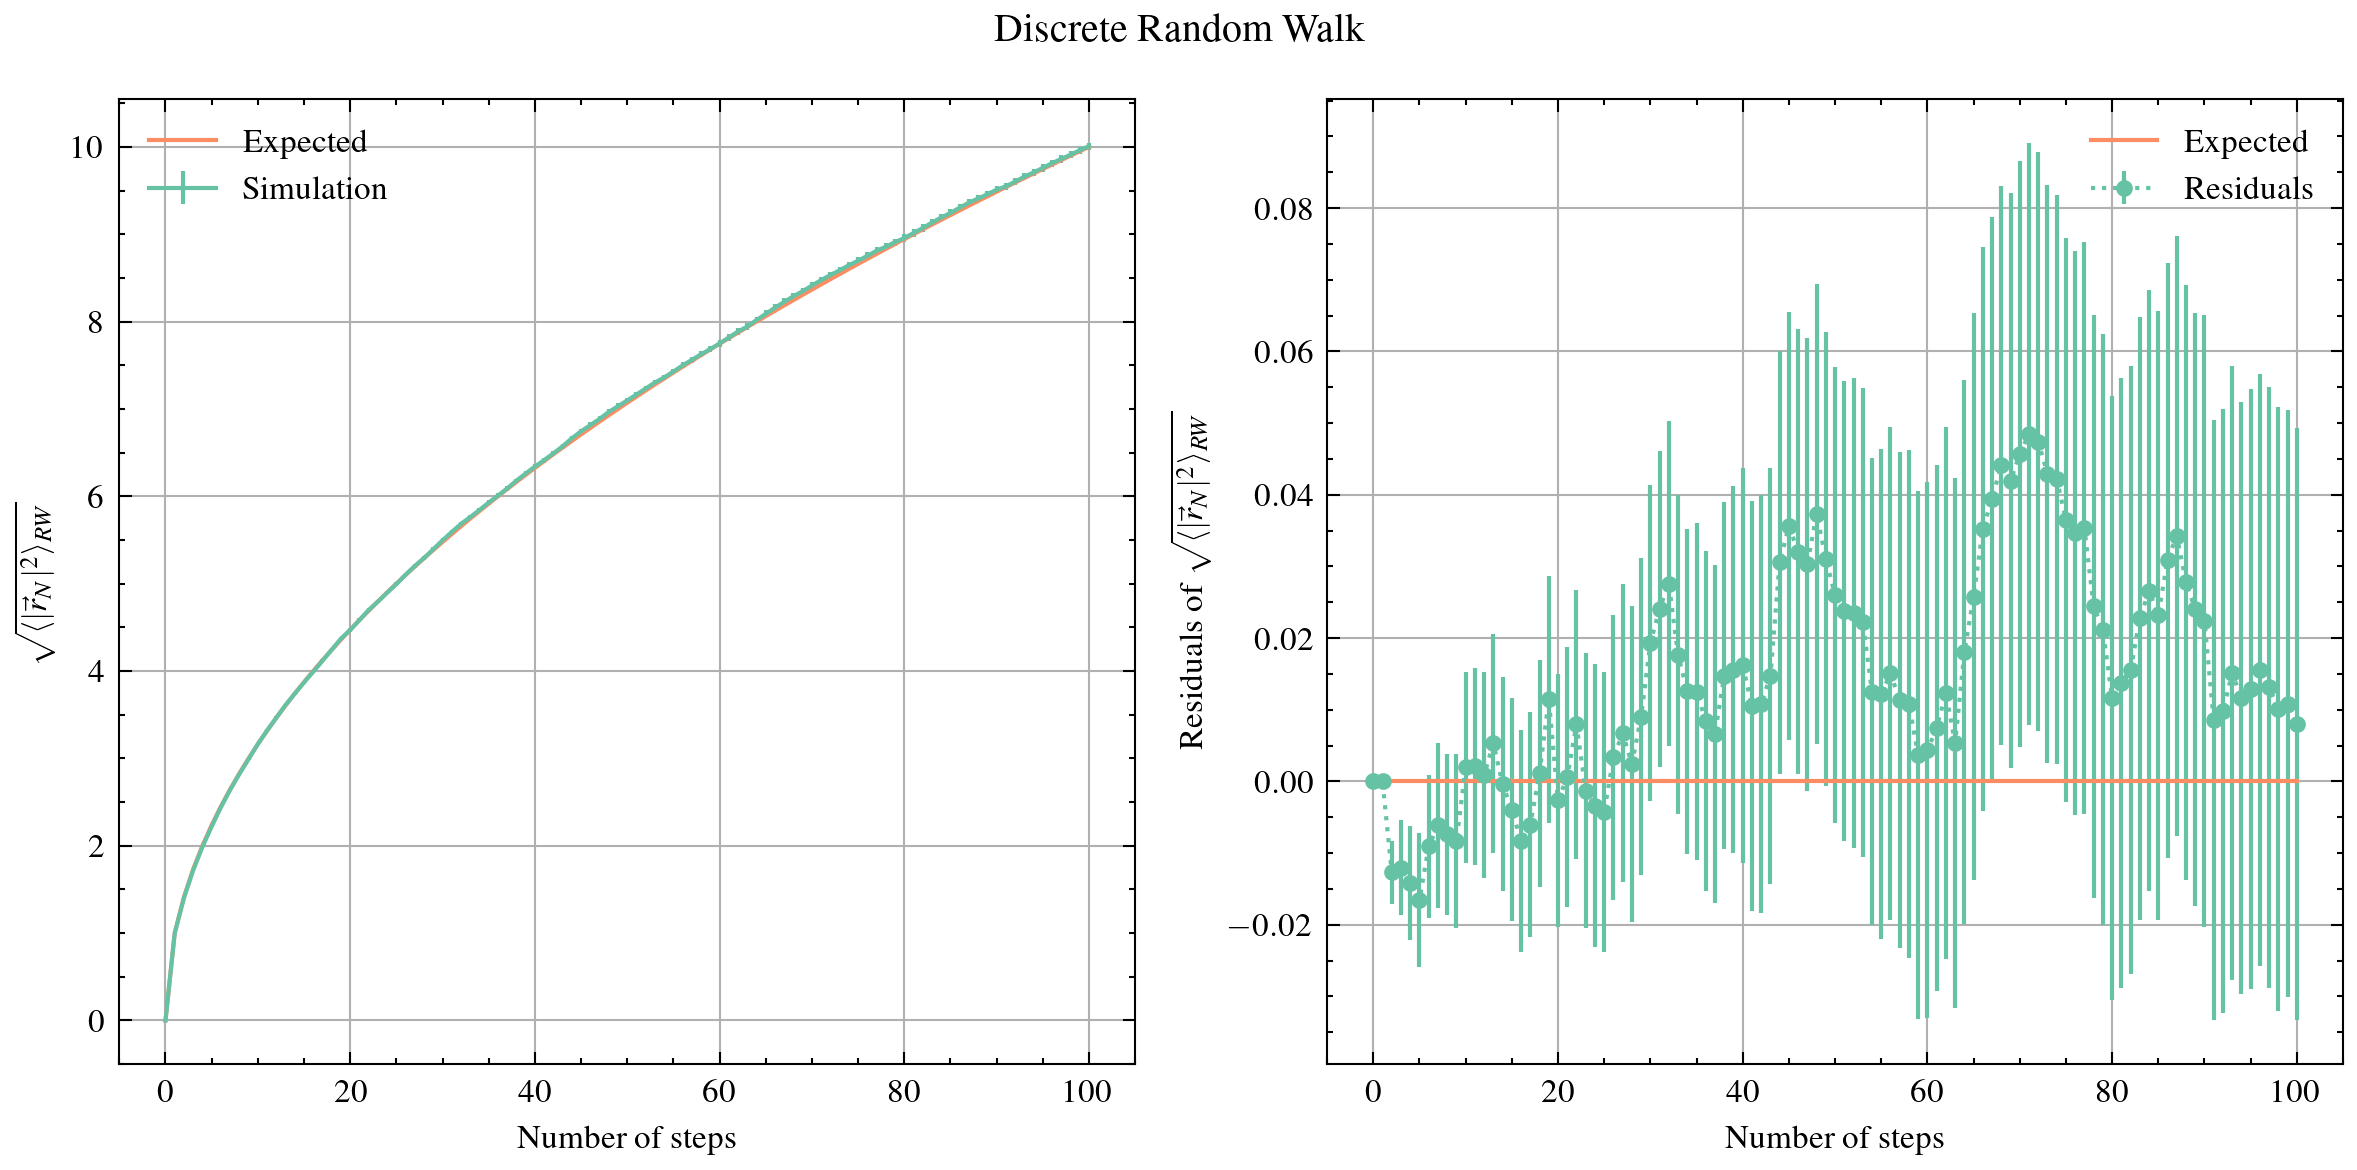

In [6]:
plot_random_walk(
    "./Exer_02_02/steps_discrete.dat",
    "Discrete Random Walk",
)

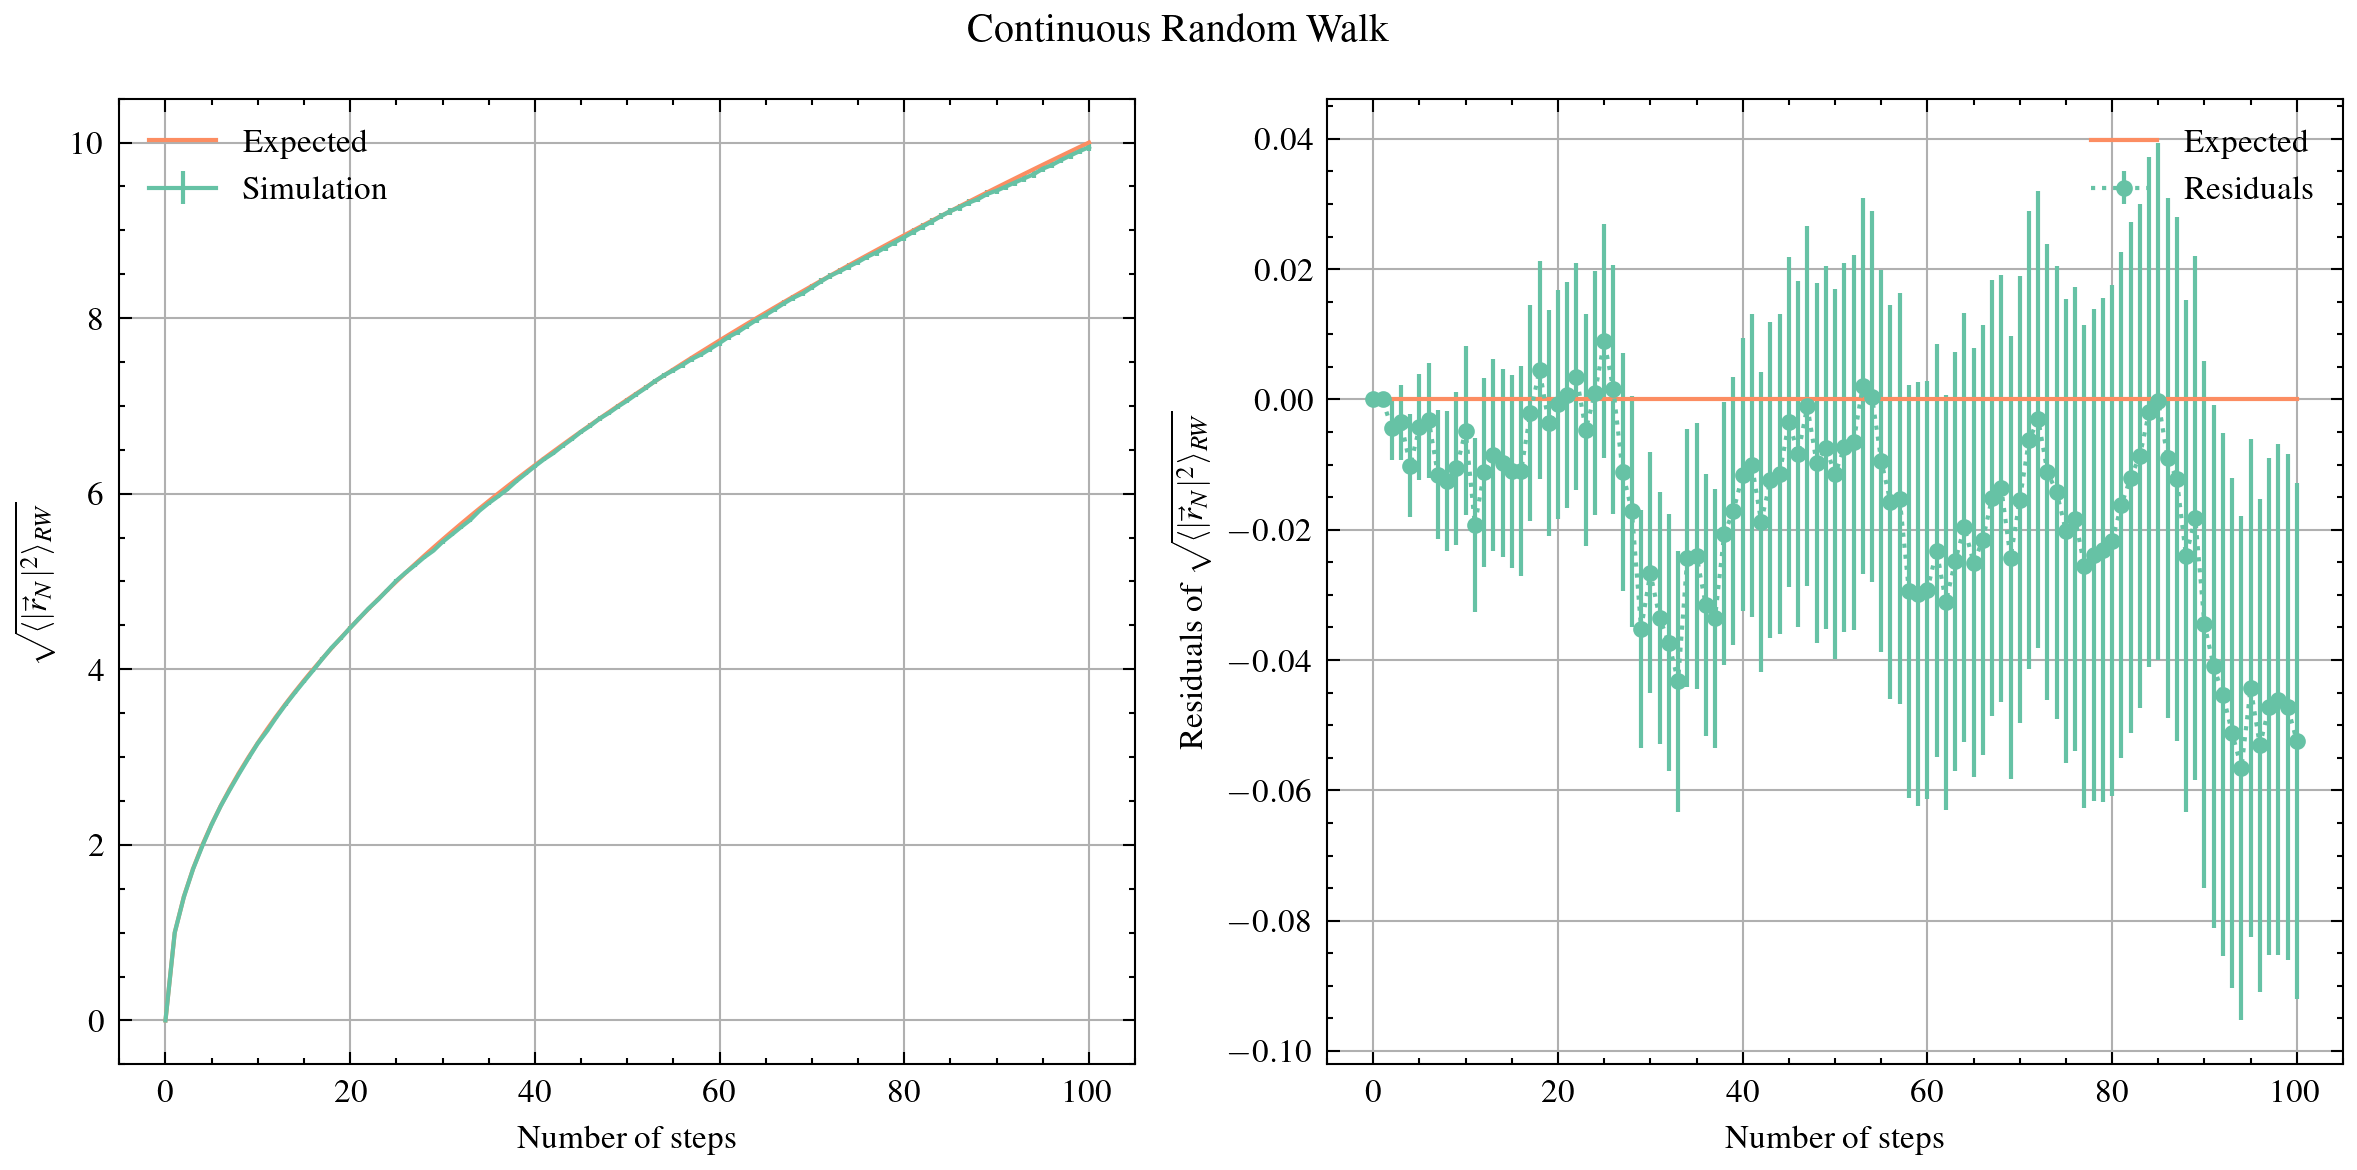

In [7]:
plot_random_walk(
    "./Exer_02_02/steps_continuos.dat",
    "Continuous Random Walk",
)

We can see that our results have a good fit with the expected result $\sqrt{\langle |\vec{r}_N|^2 \rangle} = \sigma_l \sqrt{N}$, where $N$ is the number of steps, and $\sigma_l$ is the variance of a single step, in our cases $\sigma_l = 1$.

We can also note that the error increases with the number of steps, which is what we expect for a diffuse behavior.